In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
df_ap = pd.read_csv('../Academic_Performance.csv')

In [4]:
df_ap['Score'] = df_ap['Score'].fillna(df_ap['Score'].mean())
df_ap = df_ap.fillna(df_ap.mode().iloc[0])

In [5]:
numeric_cols = df_ap.select_dtypes(include=[np.number]).columns
z_scores = ((df_ap[numeric_cols] - df_ap[numeric_cols].mean()) / df_ap[numeric_cols].std()).abs()
outlier_mask = (z_scores >= 3).any(axis=1)
outliers = df_ap[outlier_mask]
print('Outliers rows:', outliers.shape[0])

Outliers rows: 0


In [6]:
df_ap_clean = df_ap[~outlier_mask].copy()

In [7]:
df_ap_clean['Grade'] = pd.cut(df_ap_clean['Marks'], bins=[0, 40, 70, 100], labels=['Low', 'Avg', 'High'])


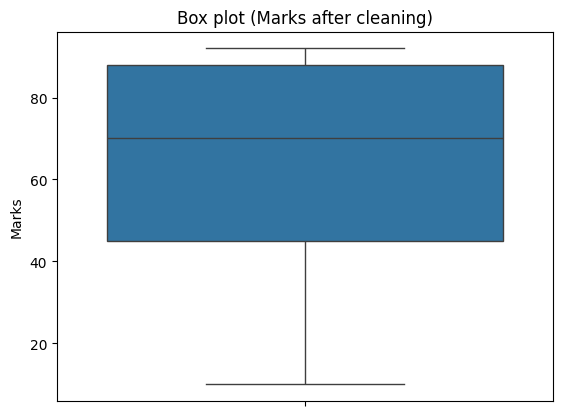

,RollNo,Name,Score,Age,Marks,Grade
0,1,Sita,85.0,20,88,High
1,2,Gita,90.0,21,92,High
2,3,Ram,100.0,20,45,Avg
3,4,Sham,150.0,22,70,Avg
4,5,Tina,75.0,19,10,Low


In [8]:
sns.boxplot(y=df_ap_clean['Marks'])
plt.title('Box plot (Marks after cleaning)')
plt.show()

df_ap_clean.head()